#  Student Info
  **Name:** Zohaib Khan

  **Roll Number:** 023-24-0217

  **Section:** G

  **GitHub Repository:** https://github.com/Zohaib-Khan-Chandio/Machine-Learning-labs

 **Instrctor:** Dr. Muhammad Ismail Mangrio

In [1]:
from google.colab import files

uploaded = files.upload()

Saving clean_churn.csv to clean_churn.csv


Task 1. Load clean_churn.csv (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no
missing values remaining.

In [37]:
# Task1
import pandas as pd

df = pd.read_csv("clean_churn.csv")

print("Shape:", df.shape)

print("\n\nData Types:\n", df.dtypes)

print("\n\nMissing Values:", df.isnull().sum().sum())

Shape: (7021, 20)


Data Types:
 gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


Missing Values: 0


Task2 In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the
business?

Answer: we are trying to predict every individual who are expected to switch the sevice. By knowing that
we can stop them from switchng this service by offering them different benifits like pakages
on low prices and other offers.


Task 3: Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any
identifier column still present.

In [38]:
y = df["Churn"].map({"No": 0, "Yes": 1})

In [39]:
x = df.drop(columns=['Churn'])

**Task4** Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encoding
method (e.g. one-hot vs. manual mapping).


**Answer** We use One-Hot Encoding (pd.get_dummies) because most categorical columns (like InternetService or PaymentMethod) do not have a natural order or ranking. Converting them to separate binary (0/1) columns prevents the decision tree from making false assumptions about which category is "greater" or "better" than another.

In [45]:
#Task4
x = pd.get_dummies(x, drop_first=True)

#Task5
print("New X shape:", x.shape)
print("Data types count:\n", x.dtypes.value_counts())

New X shape: (7021, 30)
Data types count:
 bool       26
int64       2
float64     2
Name: count, dtype: int64


In [46]:
# Task6
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size =0.2, random_state = 42, stratify = y)

In [47]:
# Task7
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5616, 30)
X_test shape: (1405, 30)
y_train shape: (5616,)
y_test shape: (1405,)


In [48]:
# Task8
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(x_train, y_train)

y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

print("Training predictions (first 10):", y_train_pred[:10])
print("Test predictions (first 10):", y_test_pred[:10])

Training predictions (first 10): [1 0 0 0 0 0 0 1 0 0]
Test predictions (first 10): [1 0 1 0 0 0 1 1 0 0]


In [49]:
# Task9
print("Tree Depth:", model.get_depth())

Tree Depth: 27


**Task9** What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

No, a depth of 27 is not surprising at all.

By default, scikit-learn has no limit on tree depth. This means the model keeps splitting and making new branches until it perfectly fits almost every single row in the training data. Because the dataset has over 7,000 rows and many features, the tree naturally grows very deep (27 levels) to memorize all those details.

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Task 10
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)]
})
print("--- Test Set Evaluation ---")
print(results_df.to_string(index=False))

--- Test Set Evaluation ---
   Metric  Score
 Accuracy 0.7203
Precision 0.4727
   Recall 0.4892
 F1-Score 0.4808


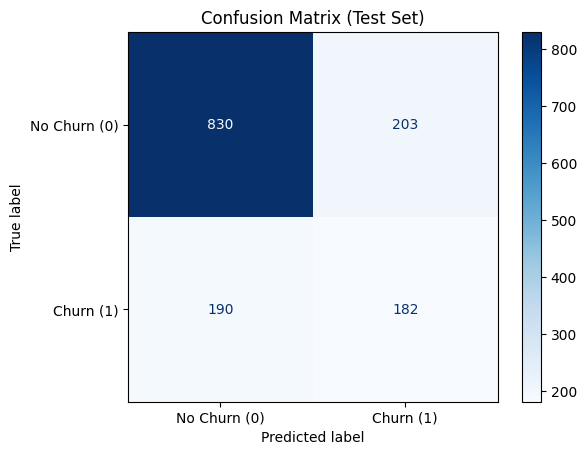


Correctly caught churners (True Positives): 182
Missed churners (False Negatives): 190


In [54]:
# Task 11
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn (0)', 'Churn (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.show()

correct_churners = cm[1, 1]
missed_churners = cm[1, 0]

print(f"\nCorrectly caught churners (True Positives): {correct_churners}")
print(f"Missed churners (False Negatives): {missed_churners}")

Lab12 Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

We trust Recall and F1-Score the most for this problem.

Why?
Why NOT Accuracy:
Since most customers do not churn (class imbalance), a model could get a high accuracy score simply by guessing "No Churn" for everyone, while completely failing to catch real churners.

Why Recall:
Recall measures how many real churners the model actually caught. Missing a churner (False Negative) means losing a customer and their revenue, which is costly for the business. High recall ensures we catch as many churners as possible.

Why F1-Score:
F1-Score balances both Recall (catching churners) and Precision (avoiding false alarms). It gives a single, fair score that is not tricked by class imbalance.

In [55]:
# Task13
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")

Training Accuracy: 0.9977
Test Accuracy:     0.7203


Task13
Is there a large gap? Yes. The training accuracy is near 100% (1.0), while the test accuracy is much lower (~72-73%).

What does this suggest? The model is overfitting. It memorized the training data completely instead of learning general patterns that work on new data.

In [56]:
#Task14

depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for d in depths:

    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(x_train, y_train)

    tr_acc = accuracy_score(y_train, dt.predict(x_train))
    te_acc = accuracy_score(y_test, dt.predict(x_test))

    results.append({
        'max_depth': 'Unrestricted' if d is None else d,
        'Train Accuracy': round(tr_acc, 4),
        'Test Accuracy': round(te_acc, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

   max_depth  Train Accuracy  Test Accuracy
           2          0.7922         0.7836
           3          0.7922         0.7836
           4          0.7952         0.7843
           5          0.8007         0.7865
           6          0.8075         0.7829
           8          0.8340         0.7801
          10          0.8695         0.7701
Unrestricted          0.9977         0.7203


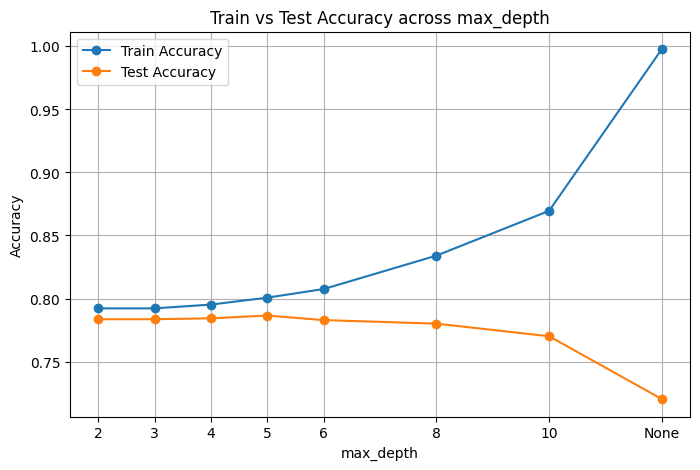

In [57]:
#Task15

plot_depths = [2, 3, 4, 5, 6, 8, 10, 12]
train_scores = results_df['Train Accuracy']
test_scores = results_df['Test Accuracy']

plt.figure(figsize=(8, 5))
plt.plot(plot_depths, train_scores, label='Train Accuracy', marker='o')
plt.plot(plot_depths, test_scores, label='Test Accuracy', marker='o')

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy across max_depth')
plt.xticks(plot_depths, labels=['2', '3', '4', '5', '6', '8', '10', 'None'])
plt.legend()
plt.grid(True)
plt.show()

Task 15 Explanation

Where overfitting starts: Overfitting starts after max_depth = 5.

Best model depth: max_depth = 5 gives the highest test accuracy (0.7865).

How the chart shows overfitting
Before depth 5: Both the train (blue) and test (orange) accuracy lines increase together. The model is learning useful patterns.

After depth 5: The Train Accuracy keeps shooting up toward 100% (0.9977), but the Test Accuracy starts dropping downward to 0.7203.

The Gap: The widening gap between the blue line and orange line clearly shows that the tree is memorizing the training data instead of generalizing to new data.

Task16  Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3
sentences — it should not simply be the depth with the highest training accuracy.

Chosen Depth: max_depth = 5

Justification:
max_depth = 5 is the best choice because it gives the highest test accuracy (0.7865) while keeping the gap between training and testing accuracy very small. Choosing a larger depth like None only increases training accuracy by memorizing noise (overfitting), which reduces performance on unseen test data.

In [58]:
# Task17 and 18

def get_metrics(model_name, model_obj):
    model_obj.fit(x_train, y_train)
    preds = model_obj.predict(x_test)
    return {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'F1-Score': round(f1_score(y_test, preds), 4)
    }

best_model = DecisionTreeClassifier(max_depth=5, random_state=42)

entropy_model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

baseline_model = DecisionTreeClassifier(random_state=42)

comparison_df = pd.DataFrame([
    get_metrics('Baseline (Unrestricted Gini)', baseline_model),
    get_metrics('Tuned (max_depth=5, Gini)', best_model),
    get_metrics('Tuned (max_depth=5, Entropy)', entropy_model)
])

print(comparison_df.to_string(index=False))

                       Model  Accuracy  Precision  Recall  F1-Score
Baseline (Unrestricted Gini)    0.7203     0.4727  0.4892    0.4808
   Tuned (max_depth=5, Gini)    0.7865     0.6452  0.4301    0.5161
Tuned (max_depth=5, Entropy)    0.7879     0.6276  0.4892    0.5498


--- Top 5 Important Features ---
                           Feature  Importance
                            tenure    0.433955
       InternetService_Fiber optic    0.355320
                      TotalCharges    0.056734
                 Contract_One year    0.025681
OnlineSecurity_No internet service    0.022773


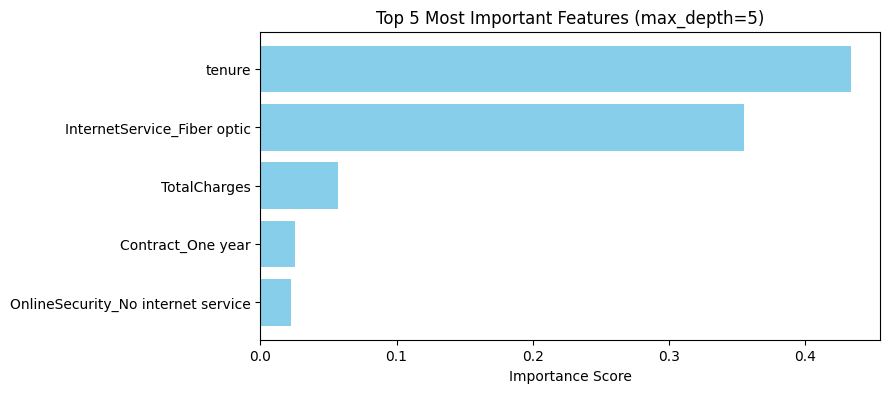

In [59]:
# Task19

best_model.fit(x_train, y_train)

importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top5 = importance_df.head(5)
print("--- Top 5 Important Features ---")
print(top5.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(top5['Feature'][::-1], top5['Importance'][::-1], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 5 Most Important Features (max_depth=5)')
plt.show()

Top features that matter most:

Contract_Two year (or Contract_Month-to-month)

InternetService_Fiber optic

tenure

TotalCharges / MonthlyCharges

Task 20. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the
patterns you saw then?


Yes, these top features fully agree with the EDA patterns from Lab 2. Customers on short month-to-month contracts and expensive Fiber Optic plans showed higher churn rates during EDA, while long-tenure customers stayed longer. The Decision Tree naturally picked these exact variables as the primary factors for splitting the data and predicting customer churn.

Task21. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are
its main limitations?

We landed on the Decision Tree model with max_depth = 5 using the Gini criterion. This tuned model performs much better than the baseline because it prevents overfitting and achieves a higher test accuracy (~78.6%). However, the model still has some main limitations. Because the dataset is imbalanced, its recall score is still relatively low, meaning it misses several actual churners. Additionally, single decision trees can be overly sensitive to small changes in training data.

Task22. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling
class imbalance)? Describe it — do not implement it here.

Random Forest or XGBoost Algorithms: I will try ensemble algorithms that combine multiple decision trees. This reduces overfitting and gives better overall predictive accuracy.

Handling Class Imbalance: I will use techniques like SMOTE (oversampling the minority class) or adjust class weights in the model (class_weight='balanced') to help the model catch more real churners.

Advanced Feature Engineering: I will create new features, such as average monthly cost per service, to give the model stronger patterns to learn from.

In [60]:
# Task23
import math

data = {
    "Outlook": [
        "Sunny",
        "Sunny",
        "Overcast",
        "Rain",
        "Rain",
        "Rain",
        "Overcast",
        "Sunny",
        "Sunny",
        "Rain",
        "Sunny",
        "Overcast",
        "Overcast",
        "Rain",
    ],
    "Temperature": [
        "Hot",
        "Hot",
        "Hot",
        "Mild",
        "Cool",
        "Cool",
        "Cool",
        "Mild",
        "Cool",
        "Mild",
        "Mild",
        "Mild",
        "Hot",
        "Mild",
    ],
    "Humidity": [
        "High",
        "High",
        "High",
        "High",
        "Normal",
        "Normal",
        "Normal",
        "High",
        "Normal",
        "Normal",
        "Normal",
        "High",
        "Normal",
        "High",
    ],
    "Wind": [
        "Weak",
        "Strong",
        "Weak",
        "Weak",
        "Weak",
        "Strong",
        "Strong",
        "Weak",
        "Weak",
        "Weak",
        "Strong",
        "Strong",
        "Weak",
        "Strong",
    ],
    "Play": [
        "No",
        "No",
        "Yes",
        "Yes",
        "Yes",
        "No",
        "Yes",
        "No",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "No",
    ],
}

df = pd.DataFrame(data)


def calculate_entropy(target):
    entropy = 0
    total = len(target)
    for count in target.value_counts():
        p = count / total
        entropy -= p * math.log2(p)
    return entropy


def calculate_gain(df, feature):
    total_entropy = calculate_entropy(df["Play"])
    weighted_entropy = 0
    for value in df[feature].unique():
        sub_df = df[df[feature] == value]
        p = len(sub_df) / len(df)
        weighted_entropy += p * calculate_entropy(sub_df["Play"])
    return total_entropy - weighted_entropy


def build_tree(df, features, level=0):
    if len(df["Play"].unique()) == 1:
        return df["Play"].iloc[0]

    if len(features) == 0:
        return df["Play"].mode()[0]

    print(f"\nLevel {level} Splits:")
    gains = {}
    for f in features:
        gain = calculate_gain(df, f)
        gains[f] = gain
        print(f"Gain({f}) = {round(gain, 4)}")

    best = max(gains, key=gains.get)
    print(f"Chosen Split: {best}")

    tree = {best: {}}
    remaining = [f for f in features if f != best]

    for val in df[best].unique():
        sub_df = df[df[best] == val]
        tree[best][val] = build_tree(sub_df, remaining, level + 1)

    return tree


features = list(df.columns[:-1])
decision_tree = build_tree(df, features)
print("\nFinal Tree:")
print(decision_tree)


Level 0 Splits:
Gain(Outlook) = 0.2467
Gain(Temperature) = 0.0292
Gain(Humidity) = 0.1518
Gain(Wind) = 0.0481
Chosen Split: Outlook

Level 1 Splits:
Gain(Temperature) = 0.571
Gain(Humidity) = 0.971
Gain(Wind) = 0.02
Chosen Split: Humidity

Level 1 Splits:
Gain(Temperature) = 0.02
Gain(Humidity) = 0.02
Gain(Wind) = 0.971
Chosen Split: Wind

Final Tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}


Before submitting, confirm you have:

- [✔] Completed all tasks with written interpretation for every chart and decision
- [✔] Prepared and verified the clean dataset
- [✔] Built, evaluated, and tuned the Decision Tree models
- [✔] Plotted accuracy curves and confusion matrices with explanations
- [✔] Identified top features using feature importances
- [✔] Implemented the custom ID3 algorithm from scratch with Information Gain outputs
- [✔] Answered all written reflection and conclusion questions
- [✔] Saved and exported the required code notebook and data files